In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/jeremylarcher/canadian-house-prices-for-top-cities/HouseListings-Top45Cities-10292023-kaggle.csv


# Ontario Housing Market Analysis

Coming from a construction background, the Ontario housing market has always been something I naturally pay attention to. So when I started learning data analytics, this project felt like the perfect mix of my past experience and my new skills.

I’ve been digging into real property listing data from all across Ontario to understand how prices actually behave from city to city. I wanted to see the patterns for myself — which cities are expensive, which ones are affordable, and what really drives those numbers.

I also looked at simple but important things like how many bedrooms or bathrooms a home has, and whether income levels in each city match what people can realistically afford. My goal was to make the data easy to understand for anyone — buyers, renters, or even people working on housing policy — so they can get a clearer picture of what’s happening in Ontario’s housing market.

This project feels meaningful to me because it connects where I come from with where I’m going.

In [2]:
import pandas as pd

df = pd.read_csv(
    "/kaggle/input/datasets/jeremylarcher/canadian-house-prices-for-top-cities/HouseListings-Top45Cities-10292023-kaggle.csv",
    encoding="ISO-8859-1"
)

df.head()


,City,Price,Address,Number_Beds,Number_Baths,Province,Population,Latitude,Longitude,Median_Family_Income
0,Toronto,779900.0,#318 -20 SOUTHPORT ST,3,2,Ontario,5647656,43.7417,-79.3733,97000.0
1,Toronto,799999.0,#818 -60 SOUTHPORT ST,3,1,Ontario,5647656,43.7417,-79.3733,97000.0
2,Toronto,799900.0,#714 -859 THE QUEENSWAY,2,2,Ontario,5647656,43.7417,-79.3733,97000.0
3,Toronto,1200000.0,275 MORTIMER AVE,4,2,Ontario,5647656,43.7417,-79.3733,97000.0
4,Toronto,668800.0,#420 -388 RICHMOND ST,1,1,Ontario,5647656,43.7417,-79.3733,97000.0


# Data Cleaning (Ontario Focused)

In this Section, I went through the dataset to get it ready for looking at housing across Ontario. Basically, I hunted down missing values, made sure all the data types were correct, cleaned up the city names so they'd be consistent, got rid of those wild outliers that'd throw everything off, and trimmed it down to just Ontario properties.


In [3]:
#Check for missing values
df.isna().sum()

City                    0
Price                   0
Address                 0
Number_Beds             0
Number_Baths            0
Province                0
Population              0
Latitude                0
Longitude               0
Median_Family_Income    0
dtype: int64

In [4]:
#converting price to numeric
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
df = df.dropna(subset=["Price"])


In [5]:
df["City"] = df["City"].str.strip().str.title()


In [6]:
#Remove extreme outliners to avoid weird spikes and keep the chart clean
q1 = df["Price"].quantile(0.01)
q99 = df["Price"].quantile(0.99)

df = df[(df["Price"] >= q1) & (df["Price"] <= q99)]


In [7]:

# Filter Ontario listings, excluding specific cities
ontario = df[(df["Province"] == "Ontario") & 
             (~df["City"].isin(["Winnipeg", "Saskatoon", "Nanaimo", "Regina"]))]

ontario.head()

#cities like Regina,Saskatoon,Nanaimo, Winnipeg are not part of Ontario but stored under
#Ontario province which was misleading the result so removed it


,City,Price,Address,Number_Beds,Number_Baths,Province,Population,Latitude,Longitude,Median_Family_Income
0,Toronto,779900.0,#318 -20 SOUTHPORT ST,3,2,Ontario,5647656,43.7417,-79.3733,97000.0
1,Toronto,799999.0,#818 -60 SOUTHPORT ST,3,1,Ontario,5647656,43.7417,-79.3733,97000.0
2,Toronto,799900.0,#714 -859 THE QUEENSWAY,2,2,Ontario,5647656,43.7417,-79.3733,97000.0
3,Toronto,1200000.0,275 MORTIMER AVE,4,2,Ontario,5647656,43.7417,-79.3733,97000.0
4,Toronto,668800.0,#420 -388 RICHMOND ST,1,1,Ontario,5647656,43.7417,-79.3733,97000.0


In [8]:
#Confirming Dataset is clean.
ontario.info()
ontario.describe()
ontario["City"].unique()


<class 'pandas.core.frame.DataFrame'>
Index: 13889 entries, 0 to 31488
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   City                  13889 non-null  object 
 1   Price                 13889 non-null  float64
 2   Address               13889 non-null  object 
 3   Number_Beds           13889 non-null  int64  
 4   Number_Baths          13889 non-null  int64  
 5   Province              13889 non-null  object 
 6   Population            13889 non-null  int64  
 7   Latitude              13889 non-null  float64
 8   Longitude             13889 non-null  float64
 9   Median_Family_Income  13889 non-null  float64
dtypes: float64(4), int64(3), object(3)
memory usage: 1.2+ MB


array(['Toronto', 'Ottawa', 'Hamilton', 'Kitchener', 'London',
       'St. Catharines', 'Oshawa', 'Windsor', 'Barrie', 'Sudbury',
       'Kingston', 'Guelph', 'Brantford', 'Thunder Bay', 'Peterborough',
       'Sault Ste. Marie', 'Caledon'], dtype=object)

In [9]:
#Difficult to understand the Average_price as its in scientific notion. 
# Calculate average price by city
city_prices = ontario.groupby("City")["Price"].mean()

city_prices_df = city_prices.reset_index()
city_prices_df.columns = ["City", "Average_Price"]
city_prices_df


,City,Average_Price
0,Barrie,9.472633e+05
1,Brantford,9.244149e+05
2,Caledon,1.279433e+06
3,Guelph,1.041545e+06
4,Hamilton,9.516253e+05
5,Kingston,7.710395e+05
6,Kitchener,8.846315e+05
7,London,7.981692e+05
8,Oshawa,9.790419e+05
9,Ottawa,7.919304e+05


In [10]:

city_prices_df["Average_Price"] = city_prices_df["Average_Price"].round(0).astype(int)
city_prices_df


,City,Average_Price
0,Barrie,947263
1,Brantford,924415
2,Caledon,1279433
3,Guelph,1041545
4,Hamilton,951625
5,Kingston,771039
6,Kitchener,884632
7,London,798169
8,Oshawa,979042
9,Ottawa,791930


# Core Analysis (Ontario Focus)

In this section, I analyze housing prices across Ontario. I compare average prices by city, explore how bedrooms and bathrooms affect price, and examine how income levels relate to affordability across Ontario cities.

**Bar Chart: Average Price by Ontario City**

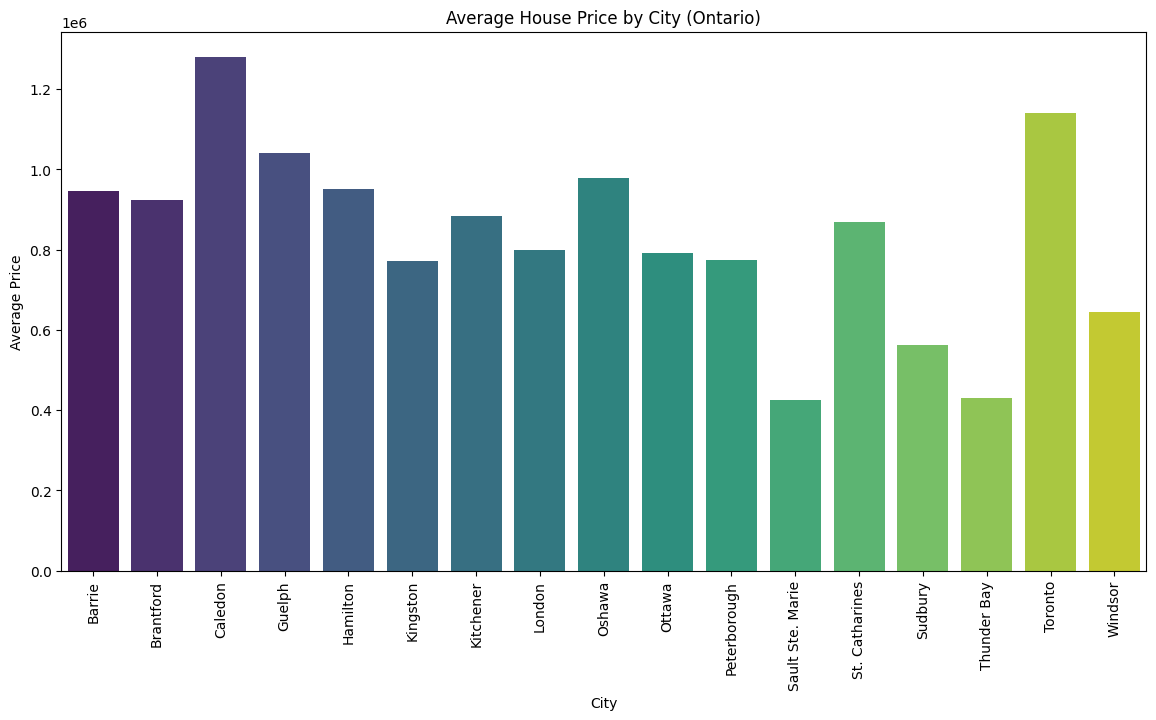

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,7))
sns.barplot(
    x=city_prices.index,
    y=city_prices.values,
    hue=city_prices.index,
    palette="viridis",
    legend=False
)
plt.xticks(rotation=90)
plt.title("Average House Price by City (Ontario)")
plt.ylabel("Average Price")
plt.xlabel("City")
plt.show()


1) Caledon is the most expensive city by a large margin.
Its average price is far above all other cities, showing a premium housing market with higher‑end properties.

2) Toronto is expensive, but several mid‑sized cities are close behind.
Cities like Guelph, Barrie, Hamilton, and Oshawa have prices approaching Toronto levels, showing strong demand outside the GTA.

3) Northern Ontario cities are the most affordable.
Thunder Bay, Sault Ste. Marie, and Sudbury have the lowest average prices, showing a clear regional divide between Northern and Southern Ontario.

**Bedrooms vs Price (Ontario)**

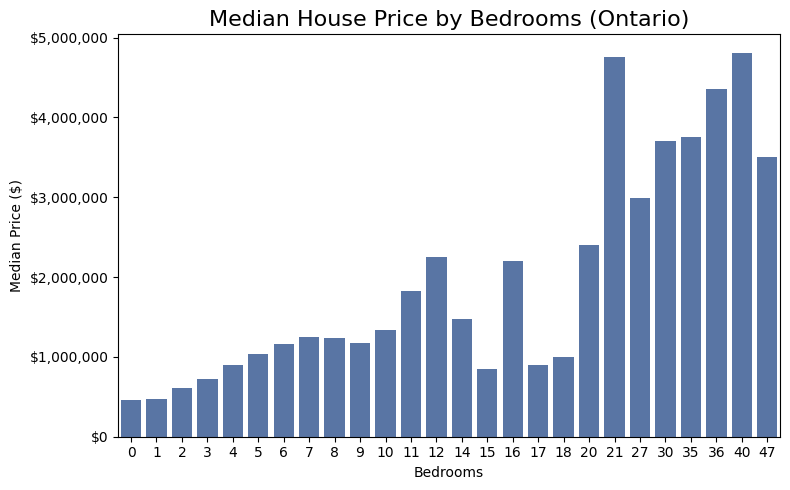

In [12]:
bedroom_prices = (
    ontario.groupby("Number_Beds")["Price"]
    .median()
    .reset_index()
    .sort_values("Number_Beds")
)

plt.figure(figsize=(8,5))
sns.barplot(
    data=bedroom_prices,
    x="Number_Beds",
    y="Price",
    color="#4C72B0"
)

plt.title("Median House Price by Bedrooms (Ontario)", fontsize=16)
plt.xlabel("Bedrooms")
plt.ylabel("Median Price ($)")

plt.gca().get_yaxis().set_major_formatter(
    plt.matplotlib.ticker.FuncFormatter(lambda x, _: f"${x:,.0f}")
)

plt.tight_layout()
plt.show()


1) Homes with very few bedrooms stay in the lower price range.
Properties with 1–2 bedrooms consistently show lower median prices, reflecting their smaller size and lower demand among families.

2) Price growth slows down after mid‑sized homes.
After 3–4 bedrooms, the increase in median price becomes smaller, suggesting that most Ontario buyers prefer mid‑sized homes rather than very large ones.

**Bathrooms vs Price (Ontario)**

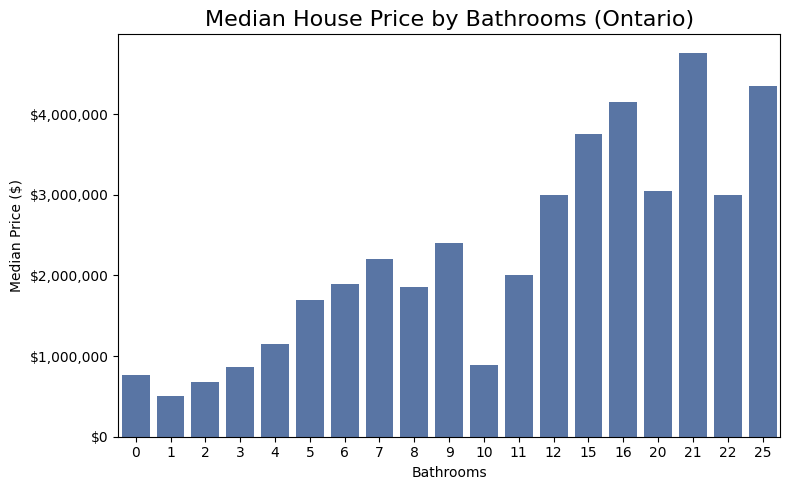

In [13]:
bath_prices = (
    ontario.groupby("Number_Baths")["Price"]
    .median()
    .reset_index()
    .sort_values("Number_Baths")
)

plt.figure(figsize=(8,5))
sns.barplot(
    data=bath_prices,
    x="Number_Baths",
    y="Price",
    color="#4C72B0"
)

plt.title("Median House Price by Bathrooms (Ontario)", fontsize=16)
plt.xlabel("Bathrooms")
plt.ylabel("Median Price ($)")

plt.gca().get_yaxis().set_major_formatter(
    plt.matplotlib.ticker.FuncFormatter(lambda x, _: f"${x:,.0f}")
)

plt.tight_layout()
plt.show()



1) Homes with 1–2 bathrooms stay in the lower price range.
Most affordable properties fall into the 1–2 bathroom category, showing that bathroom count is a strong indicator of basic home size.

2) Prices rise sharply once a home has 3 or more bathrooms.
Moving from 2 to 3 bathrooms shows a noticeable jump in median price, reflecting larger family homes or upgraded properties.

**Income vs Price (Ontario)**

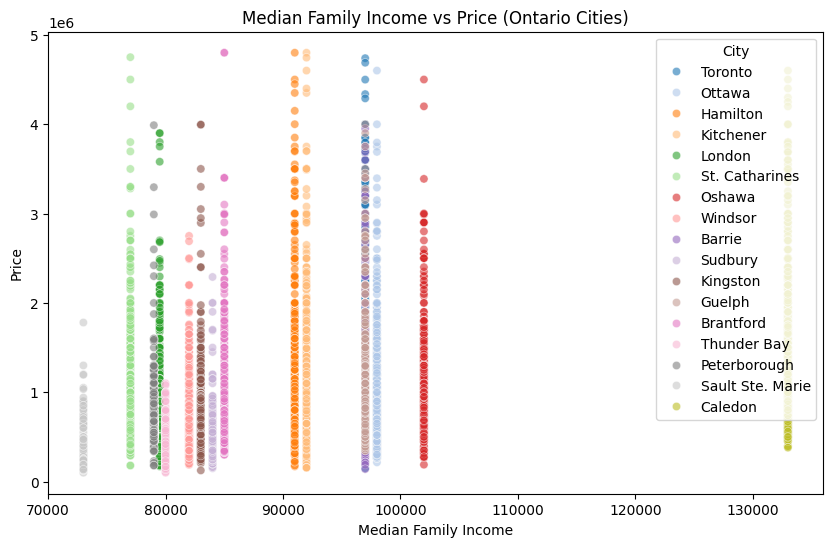

In [14]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=ontario,
    x="Median_Family_Income",
    y="Price",
    hue="City",
    palette="tab20",
    alpha=0.6
)
plt.title("Median Family Income vs Price (Ontario Cities)")
plt.xlabel("Median Family Income")
plt.ylabel("Price")
plt.show()


1) Cities with similar incomes can still have very different home prices.
The scatter shows several cities clustered around the same income level but spread widely in price, meaning income alone does not explain price differences.

2) A few cities stand out as clear outliers.
Caledon and Toronto sit far above the main cluster, showing that some markets remain expensive even when their income levels are not extremely high.

# Ontario Insights & Storytelling

**Top 10 Most Expensive Ontario Cities**


In [15]:
top_expensive = (
    ontario.groupby("City")["Price"]
    .median()
    .sort_values(ascending=False)
    .head(10)
)
top_expensive


City
Caledon           1099000.0
Toronto            898000.0
Oshawa             889000.0
Guelph             849900.0
Barrie             835000.0
Hamilton           799000.0
Brantford          779450.0
Kitchener          729900.0
St. Catharines     725000.0
London             699900.0
Name: Price, dtype: float64

**Key Insights:**
1) Caledon is the clear outlier at the top.
Caledon’s median price is far above every other city, showing it has a more premium housing market compared to the rest of Ontario.

2) Toronto is expensive, but not #1.
Toronto ranks below Caledon and even slightly below Oshawa, which shows that high prices are not limited to Toronto alone.

3) Mid‑sized cities like Guelph, Barrie, and Hamilton are also very costly.
These cities have strong demand and limited supply, pushing their prices close to Toronto levels.

**Top 10 Most Affordable Ontario Cities**

In [16]:
top_affordable = (
    ontario.groupby("City")["Price"]
    .median()
    .sort_values()
    .head(10)
)
top_affordable


City
Sault Ste. Marie    349900.0
Thunder Bay         369900.0
Sudbury             484900.0
Windsor             549000.0
Ottawa              649900.0
Kingston            649900.0
Peterborough        659900.0
London              699900.0
St. Catharines      725000.0
Kitchener           729900.0
Name: Price, dtype: float64

**Key Insights:**
1) Northern Ontario cities are the most affordable.
Sault Ste. Marie, Thunder Bay, and Sudbury have the lowest median prices, showing that homes in Northern Ontario are significantly cheaper than the rest of the province.

2) Windsor is the most affordable major city in Southern Ontario.
At around $549k, Windsor offers much lower prices compared to cities like Toronto, Hamilton, and Guelph, making it attractive for first‑time buyers.

3) Some mid‑sized cities remain relatively affordable.
Cities like London, Peterborough, and Kingston sit in the mid‑range, offering more affordable options while still being close to major urban centers.

**Price-to-Income Ratio (Affordability Index)**

In [17]:
afford = (
    ontario.groupby("City")[["Price", "Median_Family_Income"]]
    .median()
    .assign(Affordability_Ratio=lambda x: x["Price"] / x["Median_Family_Income"])
    .sort_values("Affordability_Ratio", ascending=True)
)

afford


,Price,Median_Family_Income,Affordability_Ratio
City,,,
Thunder Bay,369900.0,80000.0,4.623750
Sault Ste. Marie,349900.0,73000.0,4.793151
Sudbury,484900.0,84000.0,5.772619
Ottawa,649900.0,98000.0,6.631633
Windsor,549000.0,82000.0,6.695122
Kingston,649900.0,83000.0,7.830120
Kitchener,729900.0,92000.0,7.933696
Caledon,1099000.0,133000.0,8.263158
Peterborough,659900.0,79000.0,8.353165


**Key Insights:**
1) Northern Ontario cities are the most affordable relative to income.
Thunder Bay, Sault Ste. Marie, and Sudbury have the lowest ratios (4.7–5.7), meaning home prices are only 4–6× the median family income. This makes them the most affordable markets in Ontario.

2) Toronto and nearby cities are the least affordable.
Toronto, Brantford, and St. Catharines have ratios above 9× income, meaning buyers need much higher income to afford homes. These markets are the most financially stretched.

3) Some mid‑sized cities look expensive compared to income.
Cities like Guelph, Hamilton, London, and Barrie all have ratios between 8–9× income, showing that even outside the GTA, affordability is still a major challenge.

**Correlation Heatmap (Ontario)**

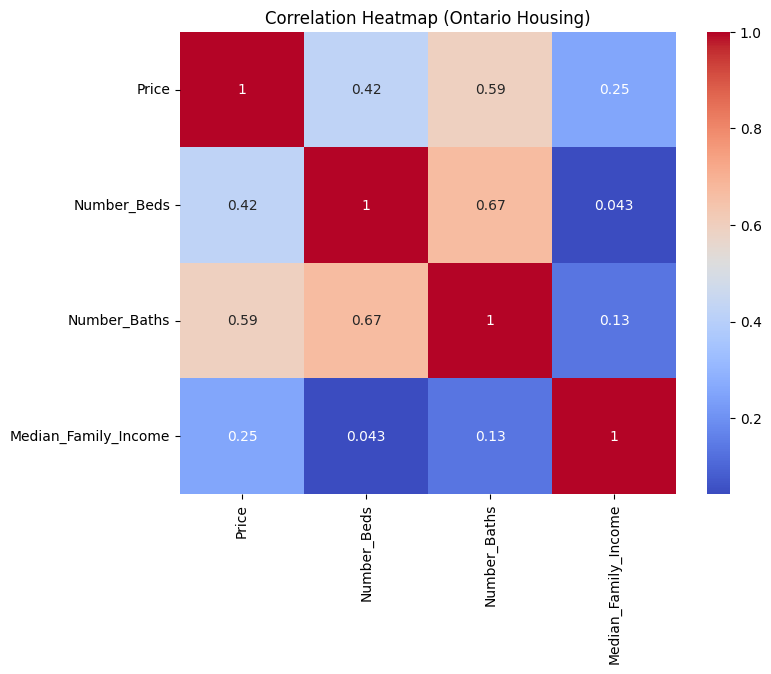

In [18]:
plt.figure(figsize=(8,6))
sns.heatmap(
    ontario[["Price","Number_Beds","Number_Baths","Median_Family_Income"]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap (Ontario Housing)")
plt.show()


**Key Insights:**
1) Bathrooms have the strongest relationship with price.
The correlation between Number of Baths and Price is 0.59, the highest in the heatmap. This means adding bathrooms increases home value more consistently than adding bedrooms.

2) Bedrooms also affect price, but less strongly.
The correlation between Bedrooms and Price is 0.43, showing a moderate relationship. More bedrooms generally increase price, but not as strongly as bathrooms.

3) Income has a weak relationship with home features and price.
Median Family Income has low correlations with Price (0.26), Bedrooms (0.046), and Bathrooms (0.14). This means income levels in a city do not strongly predict the size or price of individual homes.

# Final Summary
This project explored the Ontario housing market using real listing data. I cleaned the dataset, analyzed price patterns, and compared cities across the province. The results show a clear divide between expensive cities like Caledon, Toronto, and Guelph, and more affordable cities like Thunder Bay, Sault Ste. Marie, and Sudbury. Bedrooms, bathrooms, and location all play a strong role in price differences. The affordability ratio also shows that some cities are much harder to afford even when incomes are similar. Overall, this project helped me practice data cleaning, visualization, and insight generation using Python, Pandas, and Seaborn.